In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score


from pathlib import Path

DATA = Path("../data")
df = pd.read_csv(DATA / 'ml_sessions.csv')

In [6]:
features = ['station_age_years', 'power_kw', 'num_bays', 'hour', 'day_of_week',
            'is_weekend', 'ambient_temp_c', 'grid_load_index',
            'start_soc_pct', 'battery_capacity_kwh']

X, y = df[features], df['failed']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.25, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)

(33750, 10) (11250, 10)


In [7]:
desc = X_train.describe().T[['mean', 'std', 'min', 'max']]

print(desc.round(2))
print()
print("highest std / lowest std", round(desc['std'].max() / desc['std'].min()))

                       mean    std    min     max
station_age_years      4.49   1.71   2.00    7.00
power_kw              77.23  58.44  15.00  180.00
num_bays               3.50   1.90   1.00    8.00
hour                  13.64   6.29   0.00   23.00
day_of_week            3.00   2.01   0.00    6.00
is_weekend             0.29   0.45   0.00    1.00
ambient_temp_c        29.51   6.46  12.00   46.70
grid_load_index        0.63   0.11   0.33    0.96
start_soc_pct         40.93  16.89   5.40   89.00
battery_capacity_kwh  35.87  64.12   2.00  349.80

highest std / lowest std 586


In [8]:
raw_model = LogisticRegression()

raw_model.fit(X_train, y_train)



c:\Users\AIML\miniconda3\envs\aiml\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [9]:
raw_auc = roc_auc_score(y_test, raw_model.predict_proba(X_test)[:, 1])

print("ROC-AUC              :", round(raw_auc, 4))
print("Iterations used      :", raw_model.n_iter_ )
print("Max Iterations       :", raw_model.max_iter)

ROC-AUC              : 0.6388
Iterations used      : [100]
Max Iterations       : 100


In [10]:
raw_model_iter = LogisticRegression(max_iter=5000).fit(X_train,y_train)

raw_model_iter_auc = roc_auc_score(y_test, raw_model_iter.predict_proba(X_test)[:, 1])

print("ROC-AUC             :", round(raw_model_iter_auc, 4))
print("Iterations used     :", raw_model_iter.n_iter_)

ROC-AUC             : 0.6842
Iterations used     : [334]


In [11]:
## Without scaling the number of iterations required is
iter_without_scaling = raw_model_iter.n_iter_[0]
print(iter_without_scaling)

334


In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_train)

print(pd.DataFrame({"mean": scaler.mean_, 'scale': scaler.scale_},
                   index = features).round(2))

                       mean  scale
station_age_years      4.49   1.71
power_kw              77.23  58.44
num_bays               3.50   1.89
hour                  13.64   6.29
day_of_week            3.00   2.01
is_weekend             0.29   0.45
ambient_temp_c        29.51   6.46
grid_load_index        0.63   0.11
start_soc_pct         40.93  16.89
battery_capacity_kwh  35.87  64.12


In [13]:
X_train_s = scaler.transform(X_train)

row0 = X_train['grid_load_index'].iloc[0]
col = features.index('grid_load_index')
by_hand = (row0 - scaler.mean_[col]) / (scaler.scale_[col])
print("raw value", row0)
print("by hand", round(by_hand, 6))
print("scaler output", round(X_train_s[0, col], 6))

raw value 0.643
by hand 0.080133
scaler output 0.080133


In [14]:
by_hand == X_train_s[0, col]

np.True_

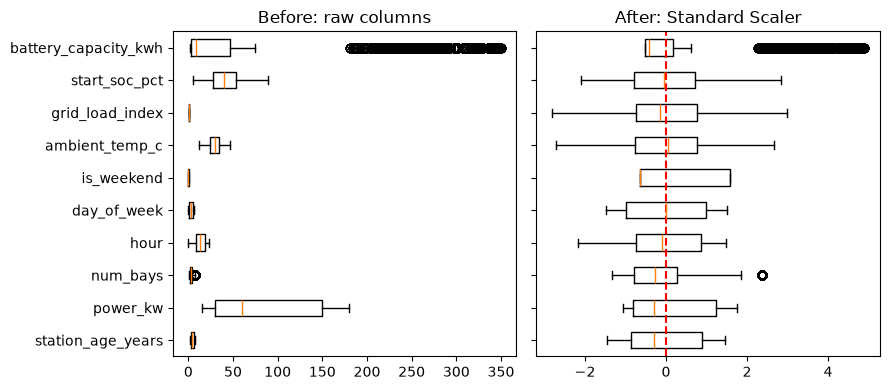

In [15]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize = (9, 4), sharey = True)
ax[0].boxplot(X_train.to_numpy(), orientation = 'horizontal')
ax[0].set_title("Before: raw columns")
ax[1].boxplot(X_train_s, orientation = 'horizontal')
ax[1].set_title("After: Standard Scaler")
ax[0].set_yticks(range(1, len(features) +1), features)
ax[1].axvline(0, color = 'red', linestyle = '--')
plt.tight_layout()

plt.show()


In [16]:
len(features)

10

In [17]:
X_train_s

array([[ 0.29873011, -0.29489121, -0.26513633, ...,  0.08013279,
        -0.85436999, -0.51881539],
       [-1.45306089, -0.29489121, -0.79284472, ..., -1.09821501,
        -0.59384918, -0.41432039],
       [ 0.29873011, -0.29489121, -0.26513633, ..., -0.16649814,
         0.44823402, -0.03533103],
       ...,
       [-1.45306089, -1.06493648, -1.32055311, ...,  0.54599123,
         1.49623815,  0.41540117],
       [-0.28520023, -0.80825472,  0.26257206, ..., -1.55493897,
         0.02192726,  0.19861302],
       [-0.86913056,  1.24519932,  0.79028045, ..., -0.41312908,
         0.77388502,  0.10347577]], shape=(33750, 10))

In [18]:
X_test_s = scaler.transform(X_test)

print(round(X_train_s.mean(), 4), X_train_s.std())
print(round(X_test_s.mean(), 4), X_test_s.std())

0.0 1.0
0.0026 0.9949243699773225


In [19]:
scaled = LogisticRegression().fit(X_train_s, y_train)
scaled_auc = roc_auc_score(y_test, scaled.predict_proba(X_test_s)[:, 1])
print(raw_model_iter_auc)
print(scaled_auc)

0.6841502299437915
0.6845480838017374


In [20]:
print(scaled.max_iter)
print(scaled.n_iter_[0])

100
9


In [21]:
print(iter_without_scaling)

334


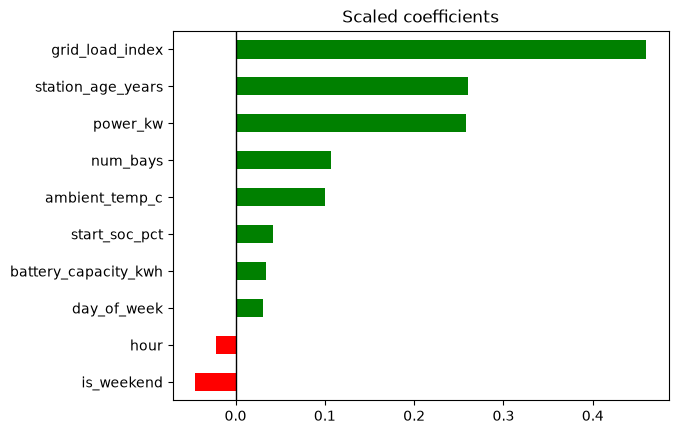

is_weekend             -0.0451
hour                   -0.0222
day_of_week             0.0310
battery_capacity_kwh    0.0346
start_soc_pct           0.0417
ambient_temp_c          0.0998
num_bays                0.1064
power_kw                0.2578
station_age_years       0.2600
grid_load_index         0.4598
dtype: float64


In [22]:
## Reading the coefficients

coefs = pd.Series(scaled.coef_[0], index = features).sort_values()
coefs.plot.barh(color = ['red' if v<0 else 'green' for v in coefs])
plt.axvline(0, color = 'black', linewidth = 1)
plt.title("Scaled coefficients")
plt.show()
print(coefs.round(4))

In [23]:
from sklearn.preprocessing import MinMaxScaler, RobustScaler

cap = X_train[['battery_capacity_kwh']]
scalers = [StandardScaler(), MinMaxScaler(), RobustScaler()]

for s in scalers:
    out = s.fit_transform(cap)
    print(f"{type(s).__name__:15} median -> {pd.Series(out[:, 0]).median():6.2f}"
          f"  max -> {out.max():6.2f}")
                                                 

StandardScaler  median ->  -0.43  max ->   4.90
MinMaxScaler    median ->   0.02  max ->   1.00
RobustScaler    median ->   0.00  max ->   7.96


In [24]:
X_train['battery_capacity_kwh'].min()

np.float64(2.0)

In [25]:
X_train['battery_capacity_kwh'].max()

np.float64(349.8)

In [26]:
X_train['battery_capacity_kwh'].median()

np.float64(8.5)

In [27]:
X_train['battery_capacity_kwh'].mean()

np.float64(35.86535111111112)

{'whiskers': [<matplotlib.lines.Line2D at 0x230a2d34170>,
 'caps': [<matplotlib.lines.Line2D at 0x230a2d34230>,
 'boxes': [<matplotlib.lines.Line2D at 0x230a2d30ec0>],
 'medians': [<matplotlib.lines.Line2D at 0x230a2d34bc0>],
 'fliers': [<matplotlib.lines.Line2D at 0x230a2d34e60>],
 'means': []}

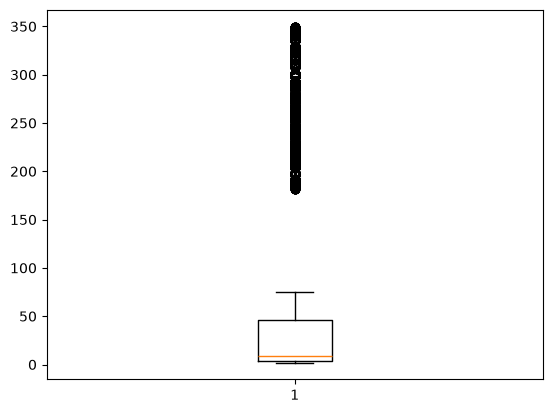

In [28]:
plt.boxplot(X_train['battery_capacity_kwh'])

## Effects of Data leakage

In [29]:
X = df[features]

In [34]:
from sklearn.preprocessing import StandardScaler

leaky_scaler = StandardScaler().fit(X)
X_train_leaky = leaky_scaler.transform(X_train)
leaky = LogisticRegression().fit(X_train_leaky, y_train)
leaky_auc = roc_auc_score(y_test, leaky.predict_proba(leaky_scaler.transform(X_test))[:, 1])

print(scaled_auc)
print(leaky_auc)

0.6845480838017374
0.6845345937659684


## Exercises to do 

1. Fit RobustScaler and print its center_ and scale_. Compare the same with StandardScaler's mean_ and scale_

2. Train the raw model with max_iter = 300, and test whether it converged

3. Whcih feature has the most negative scaled coefficient ?